**<center> <font size="4"> Laborator 2 - Continuare Spatii de Culoare </font> </center>**

Laboratorul trecut s-au tratat ideile de baza din spatele imaginilor **RGB**, precum si elemente introductorii legate de spatii de culoare alternative. In continuare se vor trata, mai in detaliu, diverse aspecte si probleme cunoscute legate de spatiile de culoare **YCbCr** si **HSV**.

#### Exercitiul 1
Cititi o imagine si convertiti imaginea in HSV. Realizati translatarea planului H cu o valoare X. Convertiti imaginea in RGB si observati ce s-a intamplat.

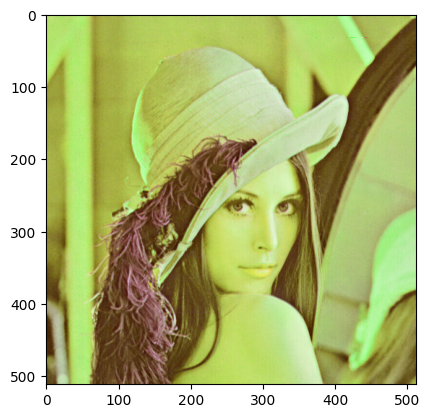

In [3]:
import numpy as np
from matplotlib import pyplot as plt
from skimage import io, color

image_rgb = io.imread('lena.png')
image_hsv = color.rgb2hsv(image_rgb)

X = 0.2
image_hsv[:,:,0] = (image_hsv[:, :, 0] + X) % 1.0 
image_rgb = color.hsv2rgb(image_hsv)
plt.imshow(image_rgb);



#### Exercitiul 2
Transformarea inversa din spatiul HSV inapoi in RGB conduce la alte valori ale planelor de culoare RGB. Din acest motiv, spatiul HSV se dovedeste a fi adesea impropriu pentru anumite sarcini de prelucrare a imaginilor. In acelasi timp, lucrul cu ideea de nuanta (hue) poate creea confuzie atunci cand vine vorba de pixelii albi (sau aproape albi) dintr-o imagine. Ce nuanta este un pixel alb (este o nuanta de rosu, de galben, etc.)? Aceeasi intrebare se poate pune si cand ne referim la zonele gri dintr-o imagine.<br>
Cititi imaginea **'Penguins.jpg'**, convertiti-o in HSV si vizualizati planul H. Ce observati in zonele albe? Sunt toate zonele albe din imagine de aceeasi nuanta?

Sfat: nu uitati sa folositi harta de culoare **'hsv'** cand vizualizati planul H.

#### Exercitiul 3
Planul H din HSV este reprezentat circular, cu nuantele modificandu-se treptat cu deplasarea fata de punctul de origine. Din acest motiv apare o problema care trebuie tratata cand se discuta despre nuantele de **rosu**. Acestea sunt situate atat la **unghiuri mici (corespunzatoare valorilor imediat mai mari ca 0) cat si la unghiuri mari (corespunzatoare valorilor imediat mai mici ca 1)**.

Din acest motiv, in diverse probleme de analiza a imaginilor, trebuie analizate cu atentie nuantele de rosu din imagine, fiindca valorile foarte mari si cele foarte mici sunt apropiate din punct de vedere perceptual.

Creati o imagine cu 128 de linii si coloane. Pe fiecare coloana a imagine reprezentati alta valoare, astfel incat pe prima coloana sa se afle (pe toate liniile) valoarea **0**, valoarea sa creasca odata cu coloana, iar pe ultima coloana sa se afle valoarea __1__. Afisati imaginea rezultata cu harta de culori <b>'hsv'</b>. Ce observati?

0.0
0.007874015748031496
0.015748031496062992
0.023622047244094488
0.031496062992125984
0.03937007874015748
0.047244094488188976
0.05511811023622047
0.06299212598425197
0.07086614173228346
0.07874015748031496
0.08661417322834646
0.09448818897637795
0.10236220472440945
0.11023622047244094
0.11811023622047244
0.12598425196850394
0.13385826771653545
0.14173228346456693
0.14960629921259844
0.15748031496062992
0.16535433070866143
0.1732283464566929
0.18110236220472442
0.1889763779527559
0.1968503937007874
0.2047244094488189
0.2125984251968504
0.2204724409448819
0.2283464566929134
0.23622047244094488
0.2440944881889764
0.25196850393700787
0.25984251968503935
0.2677165354330709
0.2755905511811024
0.28346456692913385
0.29133858267716534
0.2992125984251969
0.30708661417322836
0.31496062992125984
0.3228346456692913
0.33070866141732286
0.33858267716535434
0.3464566929133858
0.3543307086614173
0.36220472440944884
0.3700787401574803
0.3779527559055118
0.3858267716535433
0.3937007874015748
0.4015748

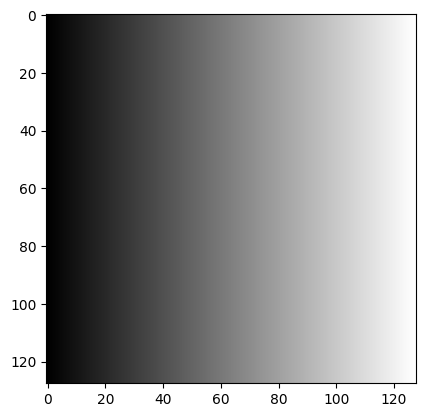

In [20]:

img = np.zeros([128, 128, 3])
img = color.rgb2hsv(img)

for col in range(128):
    img[:, col] = col / 127 
    print(col / 127)

plt.figure()
plt.imshow(img, cmap='hsv')
plt.show()

#### Exercitiul 4
Spatiul YCbCr are avantajul ca separa planul de luminanta Y de planele de crominanta (Cb,Cr), insa semnificatia acestora nu este intuitiva. Alterarea planelor de crominanta si compararea cu imaginea originala RGB poate ajuta insa in semnificatia Cb si Cr.

Incarcati imaginea **'lena.png'**, si afisati-o. Convertiti imaginea in spatiul YCbCr (functia <b>rgb2ycbcr</b>), si impartiti toate valorile din planul Cb la 2. Transformati imaginea inapoi in RGB si observati care sunt diferentele fata de original. Observati rezultatul si pentru inmultire cu o valoare. Repetati operatiile pentru planul Cr.

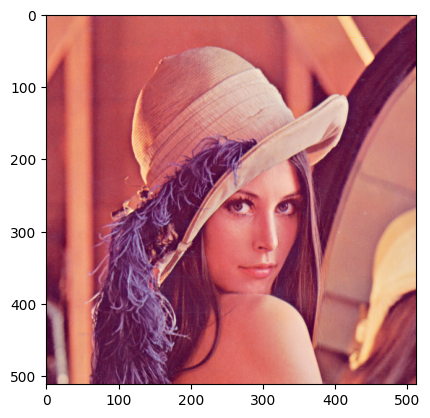

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.415430939357301..1.059538733334279].


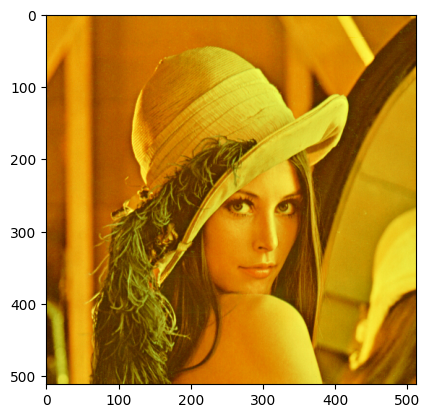

(<Figure size 640x480 with 1 Axes>,
 None)

In [32]:
img = io.imread('lena.png')
plt.figure(), plt.imshow(img), plt.show()
img_ycbcr = color.rgb2ycbcr(img)
img_ycbcr[:, :, 1] = img_ycbcr[:, :, 1] // 2
img_rgb = color.ycbcr2rgb(img_ycbcr)
plt.figure(), plt.imshow(img_rgb), plt.show()

#### Exercitiul 5
Ochiul uman este mult mai sensibil la diferentele de luminanta decat cele de crominanta. Din acest motiv, subesantionarea planelor de crominanta este o metoda des folosita pentru comprimarea informatiei video.

Incarcati imaginea **'lena.png'** si afisati-o. Convertiti imaginea din RGB in YCbCr si subesantionati planurile Cb si Cr. Pentru aceasta, selectati grupuri de catre <b>4 pixeli (2 linii si 2 coloane)</b> si inlocuiti toate valorile cu <b>media aritmetica</b> a acestora. Aceasta operatiune este echivalenta cu subesantionarea planului (pentru transmisie) si apoi supraesantionarea planului pentru afisare. Schema de mai jos ilustreaza ideea de baza a operatiilor pe care trebuie sa le efectuati. <img src='subesantionare.png'>

Convertiti imaginea inapoi in RGB si afisati. Se vede vreo diferenta notabila?
Incercati aceeasi operatie dar pe planul de luminanta.

#### Exercitiul 6
Asemenea subesantionarii, sub subcuantizarea valorilor transmise este o metoda des folosita pentru reducerea numarului de biti care trebuie transmisi. Pentru a ilustra acest aspect, incarcati imaginea **'lena.png'**, afisati-o, si convertiti in YCbCr. Grupati apoi valorile pixelilor din planele de crominanta astfel incat sa ramana 64 de valori, in loc de cele 256 folosite la codarea pe 8 biti. Convertiti in RGB si afisati rezultatul.